In [146]:
import os
import glob
import gc
import sys
import multiprocessing #needed to run pymp in mac
# multiprocessing.set_start_method('fork') #needed to run pymp in mac
import pymp
import subprocess
import numpy as np
import xarray as xr

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)

path = os.getcwd().split('/')
machine_path = f'/{path[1]}/{path[2]}' #cat the /home/user/ or /Users/user from system using path

# path_to_functions = f"{machine_path}/opt/rifting_melt/functions"
# sys.path.append(os.path.abspath(path_to_functions))

# if '' in sys.path:
#     sys.path.remove('')
from functions.mandyocIO import read_datasets, change_dataset, plot_property, find_nearest

In [2]:
model_path = '/Users/joao_macedo/Desktop/RFT_Tp1400oC'
model_name = model_path.split('/')[-1]
output_path = '_output'
print(f"Model name: {model_name}\n")
print(f"Model path: {model_path}\n")
print(f"Output path: {output_path}\n")

if not os.path.isdir(output_path):
    os.makedirs(output_path)

Model name: RFT_Tp1400oC

Model path: /Users/joao_macedo/Desktop/RFT_Tp1400oC

Output path: _output



In [3]:
plot_isotherms = True
# plot_isotherms = False
plot_melt = True
# plot_melt = False
plot_particles=False

if(plot_isotherms or plot_melt):
    clean_plot=False
else:
    clean_plot = True

datasets = [#Properties from mandyoc. Comment/uncomment to select properties of the dataset
            'density',
            'radiogenic_heat',
            'pressure',
            'strain',
            'strain_rate',### Read ascii outputs and save them as xarray.Datasets,
            # 'surface',
            'temperature',
            'viscosity',
            ]# Read data and convert them to xarray.Dataset

properties = [#Properties from mandyoc. Comment/uncomment to select which ones you would like to plot
            #  'density',
            #  'radiogenic_heat',
             'lithology',
            #  'pressure',
            #  'strain',
            #  'strain_rate',
            #  'temperature',
            #  'temperature_anomaly',
            #  'surface',
            #  'viscosity'
             ]

new_datasets = change_dataset(properties, datasets)
# print(new_datasets)
to_remove = []
remove_density=False
if ('density' not in properties): #used to plot air/curst interface
        properties.append('density')
        new_datasets = change_dataset(properties, datasets)
        to_remove.append('density')
        # remove_density=True

if ('surface' not in properties): #used to plot air/curst interface
        properties.append('surface')
        new_datasets = change_dataset(properties, datasets)
        to_remove.append('surface')
        # remove_density=True

if (plot_isotherms): #add datasets needed to plot isotherms
    if ('temperature' not in new_datasets):
        properties.append('temperature')
        new_datasets = change_dataset(properties, datasets)
        to_remove.append('temperature')

# print(f"newdatasets: {new_datasets}")

if (plot_melt): #add datasets needed to plot melt fraction
    if ('melt' not in properties):
        properties.append('melt')
    if ('incremental_melt' not in properties):
        properties.append('incremental_melt')
    new_datasets = change_dataset(properties, datasets)

    #removing the auxiliary datasets to not plot
    to_remove.append('melt')
    to_remove.append('incremental_melt')

if(clean_plot): #a clean plot
    new_datasets = change_dataset(properties, datasets)

for item in to_remove:
    properties.remove(item)
    
# dataset = read_datasets(model_path, new_datasets)

In [26]:
dataset = read_datasets(model_path, new_datasets)
lithology_dataset = xr.open_dataset(f"{model_path}/_lithology.nc")
dataset['x'] = dataset.x.values/1000
dataset['z'] = dataset.z.values[::-1]/1000
Lx = dataset.lx/1000
Lz = dataset.lz/1000
Nx = dataset.nx
Nz = dataset.nz
x = np.linspace(0, Lx, Nx)
z = np.linspace(Lz, 0, Nz)
xx, zz  = np.meshgrid(x, z)
print(f"Lx: {Lx}\n")
print(f"Lz: {Lz}\n")

/Users/joao_macedo/Desktop/RFT_Tp1400oC/_strain.nc
/Users/joao_macedo/Desktop/RFT_Tp1400oC/_density.nc
/Users/joao_macedo/Desktop/RFT_Tp1400oC/_temperature.nc
/Users/joao_macedo/Desktop/RFT_Tp1400oC/_melt.nc
/Users/joao_macedo/Desktop/RFT_Tp1400oC/_incremental_melt.nc
Lx: 1600.0

Lz: 300.0



(<xarray.DataArray 'Phi' ()> Size: 8B
 array(0.00662968)
 Coordinates:
     time     float32 4B 59.59,
 <xarray.DataArray 'Phi' ()> Size: 8B
 array(0.)
 Coordinates:
     time     float32 4B 59.59)

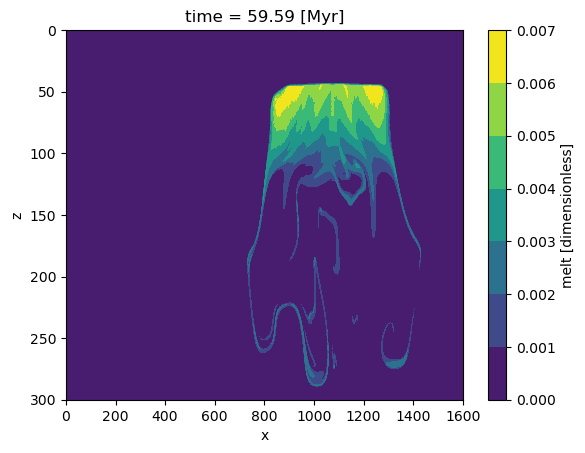

In [17]:
time_to_plot = 60
idx = find_nearest(dataset.time.values, time_to_plot)
dataset.Phi.isel(time=idx).plot.contourf(ylim=(Lz,0))

dataset.Phi.isel(time=idx).max(), dataset.Phi.isel(time=idx).min()

In [164]:
dataset.time.isel(time=idx)

<xarray.DataArray 'time' ()> Size: 4B
array(59.59, dtype=float32)
Coordinates:
    time     float32 4B 59.59
Attributes:
    units:      Myr
    long_name:  Time
    axis:       T

/Users/joao_macedo/anaconda3/envs/mpy/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/var/folders/w1/dc0mt4jd1nd9v1vy_938v2hc0000gn/T/ipykernel_46205/3484132904.py:44: UserWarning: linewidths is ignored by contourf
  axs.contourf(xx, zz, melt, levels=np.linspace(meltmin, meltmax, 5), colors=color_depleted_mantle, linewidths=0.3, alpha=0.4, zorder=20)


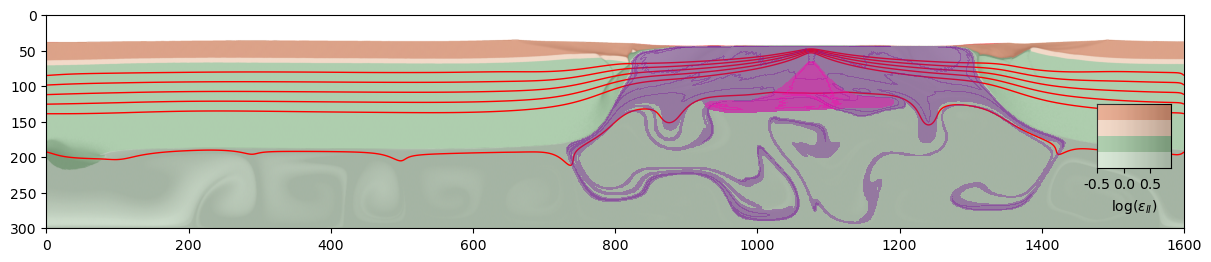

In [159]:
time_to_plot = 60
idx = find_nearest(dataset.time.values, time_to_plot)

cr = 255.
color_air = (1.,1.,1.) # 5
color_bas = (250./cr,50./cr,50./cr) # 4
color_uc = (228./cr,156./cr,124./cr) # 3
color_lc = (240./cr,209./cr,188./cr) # 2
color_lit = (155./cr,194./cr,155./cr) # 1
color_ast = (207./cr,226./cr,205./cr) # 0


colors = [color_ast,color_lit,color_lc,color_uc,color_bas,color_air]

#Creating a custom colormap according to the list of colors defined above.
# This colormap will be used to plot the lithology mesh, where each lithology type is represented by a specific color.

cmap = ListedColormap(colors)
fig, axs = plt.subplots(1, 1, figsize=(12, 3), constrained_layout=True)
            
# xlims = [0, float(data.lx) / 1.0e3]
# ylims = [-float(data.lz) / 1.0e3 + 40, 40s]
# ylims = [-150, 40]
# ylims = [-400, 40]

litho_data = lithology_dataset.lithology.isel(time=idx).to_numpy()[::-1,:]
axs.imshow(litho_data, extent=[0, Lx, Lz, 0], cmap=cmap, vmin=0, vmax=5, alpha=1.0)
axs.imshow(np.log10(dataset.strain.isel(time=idx)[::-1,:]), extent=[0,Lx,Lz,0], cmap="Greys", vmin=-0.5, vmax=0.9, alpha=0.2)
axs.contour(dataset.temperature.isel(time=idx)[::-1,:], levels=[500, 600, 700,800, 900, 1300], colors='r', linewidths=1.0)

incremental_melt = dataset.dPhi.isel(time=idx).to_numpy()[::,:]
melt = dataset.Phi.isel(time=idx).to_numpy()[::,:]

#Plotting incremental melt
color_incremental_melt = 'xkcd:bright pink'
color_depleted_mantle='xkcd:purple'

meltmin, meltmax = melt.min(), melt.max()
dmeltmin, dmeltmax = incremental_melt.min(), incremental_melt.max()
incremental_melt[incremental_melt == 0] = np.nan # Set zero values to NaN to avoid plotting them
melt[melt == 0] = np.nan # Set zero values to NaN to avoid plotting them

axs.contourf(xx, zz, incremental_melt, levels=np.linspace(dmeltmin, dmeltmax, 3), colors=color_incremental_melt, alpha=0.4, zorder=30)
axs.contourf(xx, zz, melt, levels=np.linspace(meltmin, meltmax, 5), colors=color_depleted_mantle, linewidths=0.3, alpha=0.4, zorder=20)

axs.set_xlim(0, Lx)
axs.set_ylim(Lz, 0)

bbox_to_anchor=(0.93,#horizontal position respective to parent_bbox or "loc" position
                0.25,# vertical position
                0.065,# width
                0.30)

bv1 = inset_axes(axs,
                loc='lower right',
                width="100%",  # respective to parent_bbox width
                height="100%",  # respective to parent_bbox width
                bbox_to_anchor=bbox_to_anchor,
                bbox_transform=axs.transAxes
                )

A = np.zeros((100, 10))

A[:25, :] = 2700
A[25:50, :] = 2800
A[50:75, :] = 3300
A[75:100, :] = 3400

A = A[::-1, :]

xA = np.linspace(-0.5, 0.9, 10)
yA = np.linspace(0, 1.5, 100)

xxA, yyA = np.meshgrid(xA, yA)
air_threshold = 200
bv1.contourf(
    xxA,
    yyA,
    A,
    levels=[air_threshold, 2750, 2900, 3365, 3900],
    colors=[color_uc, color_lc, color_lit, color_ast],
    extent=[-0.5, 0.9, 0, 1.5]
)

bv1.imshow(
    xxA[::-1, :],
    extent=[-0.5, 0.9, 0, 1.5],
    zorder=100,
    alpha=0.2,
    cmap=plt.get_cmap("Greys"),
    vmin=-0.5,
    vmax=0.9,
    aspect='auto'
)

bv1.set_yticklabels([])
bv1.set_xlabel(r"log$(\varepsilon_{II})$", size=10)
bv1.tick_params(axis='x', which='major', labelsize=10)
bv1.set_xticks([-0.5, 0, 0.5])
bv1.set_yticks([])
bv1.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

array([0.0000000e+00, 2.0000001e-04, 4.0000002e-04, ..., 2.9960001e-01,
       2.9979998e-01, 3.0000001e-01], shape=(1501,), dtype=float32)